<a href="https://www.kaggle.com/code/aamir28/5-000-orders-under-the-microscope?scriptVersionId=339447677" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:#FFFFFF; padding:44px 40px; border-radius:16px; border:1px solid #EAEAEE; box-shadow:0 10px 30px rgba(20,20,40,0.06); font-family:'Segoe UI',Helvetica,Arial,sans-serif;">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <div style="width:34px; height:34px; border-radius:9px; background:linear-gradient(135deg,#FF6B4A,#FF8F6B); display:flex; align-items:center; justify-content:center; font-size:17px;">🛒</div>
    <span style="font-size:12px; font-weight:700; color:#8B8B96; letter-spacing:1px; text-transform:uppercase;">Marketplace Analytics</span>
  </div>

  <h1 style="margin:0 0 8px 0; font-size:34px; color:#1A1A2E; font-weight:800; letter-spacing:-0.5px;">
    5,000 Orders Under the Microscope
  </h1>
  <p style="margin:0 0 28px 0; font-size:15.5px; color:#6E6E7E; max-width:620px;">
    Category, region, pricing, discounts and delivery — a full-funnel look at an online storefront's order history
  </p>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:14px;">
    <div style="background:#FFF4F0; border-radius:12px; padding:16px;">
      <div style="color:#FF6B4A; font-size:22px; font-weight:800;">5,000</div>
      <div style="font-size:11px; color:#8B8B96; margin-top:2px;">orders</div>
    </div>
    <div style="background:#F0F9F6; border-radius:12px; padding:16px;">
      <div style="color:#1FAE7C; font-size:22px; font-weight:800;">4</div>
      <div style="font-size:11px; color:#8B8B96; margin-top:2px;">categories</div>
    </div>
    <div style="background:#F2F0FB; border-radius:12px; padding:16px;">
      <div style="color:#7B5FE0; font-size:22px; font-weight:800;">4</div>
      <div style="font-size:11px; color:#8B8B96; margin-top:2px;">regions</div>
    </div>
    <div style="background:#FFF9EC; border-radius:12px; padding:16px;">
      <div style="color:#E0A429; font-size:22px; font-weight:800;">$5.1M</div>
      <div style="font-size:11px; color:#8B8B96; margin-top:2px;">total revenue</div>
    </div>
  </div>

  <p style="margin:22px 0 0 0; font-size:12.5px; color:#8B8B96;">
    Author: <b style="color:#1A1A2E;">Muhammad Aamir</b> &nbsp;|&nbsp; Target: <code>revenue</code> &nbsp;|&nbsp; See Section 3 before trusting the trend charts at face value
  </p>

</div>



<div style="background:#F7F7FA; border-left:4px solid #FF6B4A; border-radius:8px; padding:20px 26px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E;">
<h3 style="margin-top:0; font-weight:700; color:#FF6B4A; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#33333F;">
<li><a href="#setup" style="color:#FF6B4A; text-decoration:none;">Setup &amp; Storefront Styling</a></li>
<li><a href="#firstlook" style="color:#FF6B4A; text-decoration:none;">First Look at the Orders</a></li>
<li><a href="#quality" style="color:#FF6B4A; text-decoration:none;">Data Quality &amp; a Reality Check</a></li>
<li><a href="#category" style="color:#FF6B4A; text-decoration:none;">Category &amp; Regional Landscape</a></li>
<li><a href="#trend" style="color:#FF6B4A; text-decoration:none;">Revenue Over Time</a></li>
<li><a href="#payment" style="color:#FF6B4A; text-decoration:none;">Payment Method Patterns</a></li>
<li><a href="#service" style="color:#FF6B4A; text-decoration:none;">Ratings &amp; Delivery</a></li>
<li><a href="#pricing" style="color:#FF6B4A; text-decoration:none;">Pricing &amp; Discounts</a></li>
<li><a href="#corr" style="color:#FF6B4A; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#FF6B4A; text-decoration:none;">Storefront Dashboard</a></li>
<li><a href="#model" style="color:#FF6B4A; text-decoration:none;">Predicting Revenue</a></li>
<li><a href="#conclusion" style="color:#FF6B4A; text-decoration:none;">Closing Notes</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">⚙️ 1. Setup &amp; Storefront Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Digital Marketplace" palette ----
BG        = '#FFFFFF'
PANEL     = '#F7F7FA'
INK       = '#1A1A2E'
INK_SOFT  = '#8B8B96'
CORAL     = '#FF6B4A'
TEAL      = '#1FAE7C'
PURPLE    = '#7B5FE0'
AMBER     = '#E0A429'
BLUE      = '#3B82C4'
GRID      = '#EAEAEE'

CATEGORY_COLORS = {'Electronics': BLUE, 'Clothing': PURPLE, 'Home': TEAL, 'Beauty': CORAL}
PAYMENT_COLORS = {'Card': BLUE, 'COD': AMBER, 'Wallet': TEAL}
PALETTE_CAT = [CORAL, TEAL, PURPLE, AMBER, BLUE]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Storefront styling loaded.")


Storefront styling loaded.


<h2 id="firstlook" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">🛍️ 2. First Look at the Orders</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/abbas829/ecommerce-sales-dataset/ecommerce_sales_analytics_5000.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.head(6)


Shape: 5,000 rows x 12 columns



,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56
5,10006,2022-01-06,1071,Electronics,West,2,264.44,0.20,Card,3,3.3,423.10


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(3)
memory usage: 468.9+ KB


<h2 id="quality" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">🔍 3. Data Quality &amp; a Reality Check</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("Nulls:", df.isnull().sum().sum())
print(f"\nOrder date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Orders per calendar day: {df.groupby('order_date').size().max()} (i.e. exactly one order every single day)")

df['calc_revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'])
max_diff = (df['calc_revenue'] - df['revenue']).abs().max()
print(f"\nMax difference between revenue and quantity×price×(1-discount): {max_diff:.4f} (i.e. an exact formula)")


Duplicate rows: 0
Nulls: 0

Order date range: 2022-01-01 to 2035-09-09
Orders per calendar day: 1 (i.e. exactly one order every single day)

Max difference between revenue and quantity×price×(1-discount): 0.0050 (i.e. an exact formula)


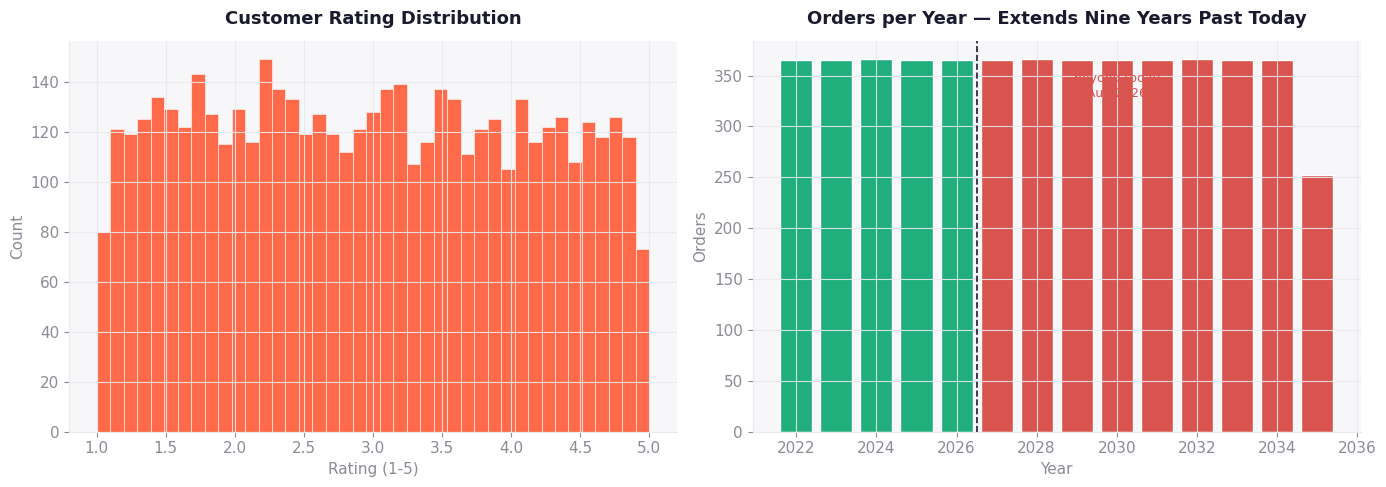

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['customer_rating'], bins=41, color=CORAL, edgecolor=BG, linewidth=0.4)
style_ax(ax, 'Customer Rating Distribution', 'Rating (1-5)', 'Count')

ax = axes[1]
yearly_orders = df.groupby(df['order_date'].dt.year).size()
colors = [TEAL if y <= 2026 else '#D9534F' for y in yearly_orders.index]
bars = ax.bar(yearly_orders.index, yearly_orders.values, color=colors, edgecolor=BG, linewidth=1.0)
ax.axvline(2026.5, color=INK, linestyle='--', linewidth=1.2)
ax.text(2030, yearly_orders.max()*0.9, 'beyond today\n(Aug 2026)', color='#D9534F', fontsize=9, ha='center')
style_ax(ax, 'Orders per Year — Extends Nine Years Past Today', 'Year', 'Orders')

plt.tight_layout()
plt.show()



<div style="background:#FFF4F0; border-left:4px solid #FF6B4A; border-radius:8px; padding:16px 22px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#33333F; font-size:14px;">
<b>Worth flagging plainly:</b> order dates run from January 2022 all the way to <b>September 2035</b> — nine years
past today — with exactly one order recorded on every single calendar day across that entire span. Customer
rating is spread almost perfectly uniformly from 1.0 to 5.0, rather than the skewed, review-bombed shape real
e-commerce ratings usually take. And <code>revenue</code> is an exact, noise-free formula
(<code>quantity × unit_price × (1 - discount)</code>) rather than something with the small real-world
rounding/tax/fee noise you'd expect. All of this points to a <b>simulated order log</b> generated on a fixed
schedule, rather than a live scrape of real transactions — a great sandbox for practicing sales analytics, but
we'll treat trend lines below as illustrative rather than a real business's actual trajectory.
</div>


<h2 id="category" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">🏷️ 4. Category &amp; Regional Landscape</h2>

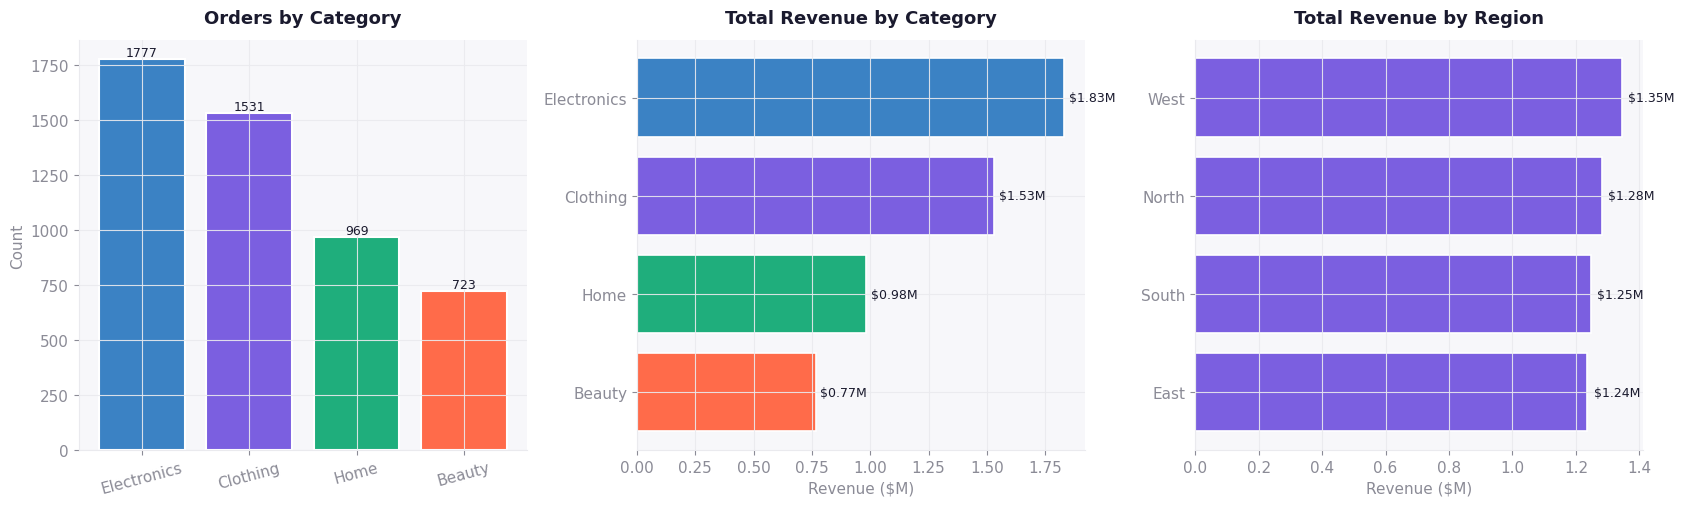

Revenue is close to evenly split across all 4 regions (within a few percent of each other) — no region
clearly dominates, consistent with the earlier finding that these fields were assigned independently.


In [6]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
cat_counts = df['product_category'].value_counts()
bars = ax.bar(cat_counts.index, cat_counts.values, color=[CATEGORY_COLORS[c] for c in cat_counts.index], edgecolor=BG, linewidth=1.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, int(b.get_height()), ha='center', fontsize=9, color=INK)
style_ax(ax, 'Orders by Category', '', 'Count')
plt.setp(ax.get_xticklabels(), rotation=15)

ax = axes[1]
cat_rev = df.groupby('product_category')['revenue'].sum().sort_values()
bars = ax.barh(cat_rev.index, cat_rev.values/1e6, color=[CATEGORY_COLORS[c] for c in cat_rev.index], edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.02, b.get_y()+b.get_height()/2, f"${b.get_width():.2f}M", va='center', fontsize=9, color=INK)
style_ax(ax, 'Total Revenue by Category', 'Revenue ($M)', '')

ax = axes[2]
region_rev = df.groupby('region')['revenue'].sum().sort_values()
bars = ax.barh(region_rev.index, region_rev.values/1e6, color=PURPLE, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.02, b.get_y()+b.get_height()/2, f"${b.get_width():.2f}M", va='center', fontsize=9, color=INK)
style_ax(ax, 'Total Revenue by Region', 'Revenue ($M)', '')

plt.tight_layout()
plt.show()

print("Revenue is close to evenly split across all 4 regions (within a few percent of each other) — no region")
print("clearly dominates, consistent with the earlier finding that these fields were assigned independently.")


<h2 id="trend" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">📈 5. Revenue Over Time</h2>

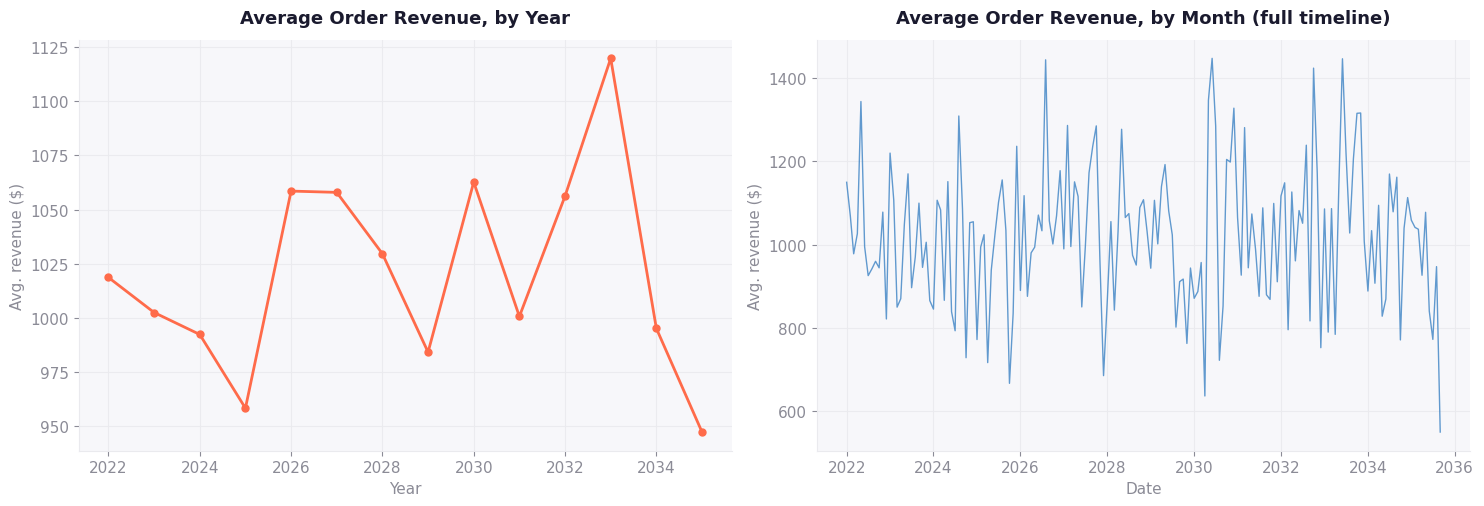

Average order revenue bounces around a flat long-run average with no visible upward or downward trend —
consistent with quantity, price and discount all being drawn independently of the order date.


In [7]:

yearly_rev = df.groupby(df['order_date'].dt.year)['revenue'].agg(['sum','mean'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

ax = axes[0]
ax.plot(yearly_rev.index, yearly_rev['mean'], color=CORAL, linewidth=2, marker='o', markersize=5)
style_ax(ax, 'Average Order Revenue, by Year', 'Year', 'Avg. revenue ($)')

ax = axes[1]
monthly_rev = df.set_index('order_date')['revenue'].resample('MS').mean()
ax.plot(monthly_rev.index, monthly_rev.values, color=BLUE, linewidth=1.0, alpha=0.8)
style_ax(ax, 'Average Order Revenue, by Month (full timeline)', 'Date', 'Avg. revenue ($)')

plt.tight_layout()
plt.show()

print("Average order revenue bounces around a flat long-run average with no visible upward or downward trend —")
print("consistent with quantity, price and discount all being drawn independently of the order date.")


<h2 id="payment" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">💳 6. Payment Method Patterns</h2>

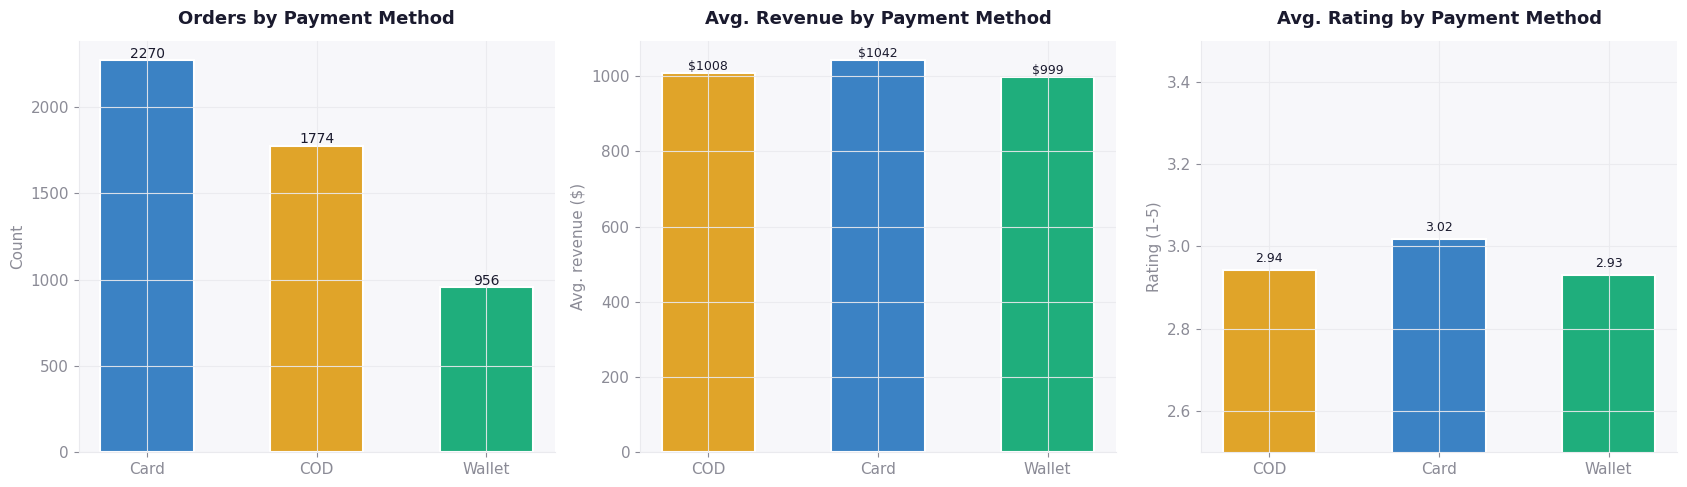

Card leads order volume, but average revenue and rating barely differ across payment methods —
payment choice doesn't appear to be linked to order size or satisfaction in this dataset.


In [8]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
pay_counts = df['payment_method'].value_counts()
bars = ax.bar(pay_counts.index, pay_counts.values, color=[PAYMENT_COLORS[p] for p in pay_counts.index], edgecolor=BG, linewidth=1.5, width=0.55)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+15, int(b.get_height()), ha='center', fontsize=10, color=INK)
style_ax(ax, 'Orders by Payment Method', '', 'Count')

ax = axes[1]
pay_rev = df.groupby('payment_method')['revenue'].mean()
bars = ax.bar(pay_rev.index, pay_rev.values, color=[PAYMENT_COLORS[p] for p in pay_rev.index], edgecolor=BG, linewidth=1.5, width=0.55)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+8, f"${b.get_height():.0f}", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Avg. Revenue by Payment Method', '', 'Avg. revenue ($)')

ax = axes[2]
pay_rating = df.groupby('payment_method')['customer_rating'].mean()
bars = ax.bar(pay_rating.index, pay_rating.values, color=[PAYMENT_COLORS[p] for p in pay_rating.index], edgecolor=BG, linewidth=1.5, width=0.55)
ax.set_ylim(2.5, 3.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f"{b.get_height():.2f}", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Avg. Rating by Payment Method', '', 'Rating (1-5)')

plt.tight_layout()
plt.show()

print("Card leads order volume, but average revenue and rating barely differ across payment methods —")
print("payment choice doesn't appear to be linked to order size or satisfaction in this dataset.")


<h2 id="service" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">⭐ 7. Ratings &amp; Delivery</h2>

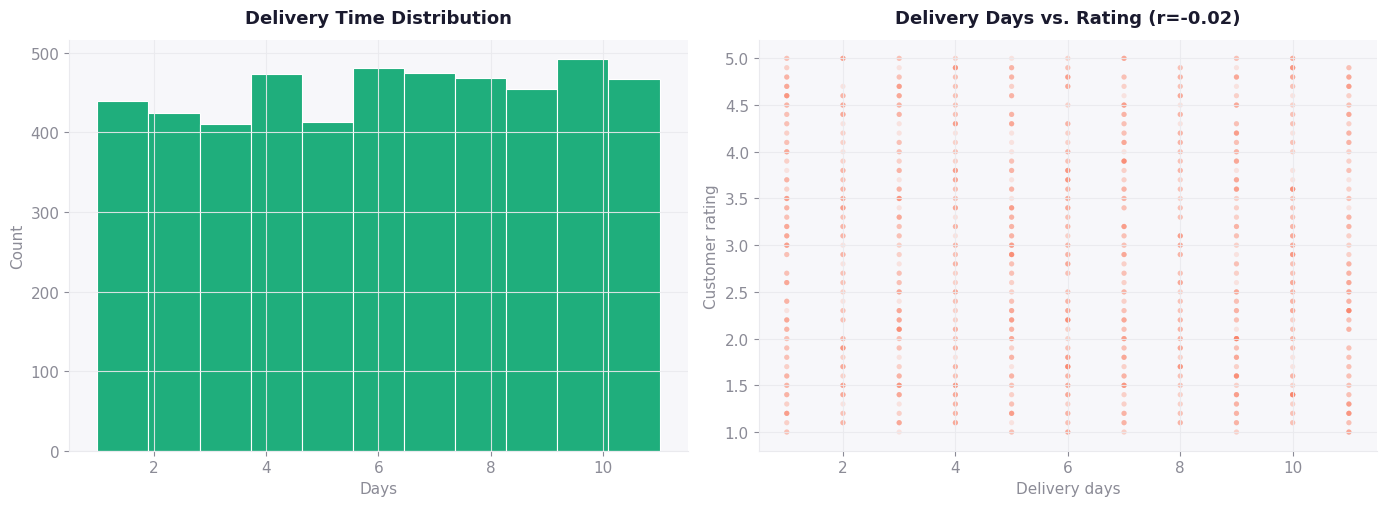

Delivery time and customer rating are essentially uncorrelated (r=-0.02) — in a real dataset, slower
delivery usually drags ratings down at least a little, so this near-zero relationship is another sign
these two fields were generated independently rather than causally linked.


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
ax.hist(df['delivery_days'], bins=11, color=TEAL, edgecolor=BG, linewidth=0.8)
style_ax(ax, 'Delivery Time Distribution', 'Days', 'Count')

ax = axes[1]
sample = df.sample(1500, random_state=1)
ax.scatter(sample['delivery_days'], sample['customer_rating'], alpha=0.15, s=14, color=CORAL, edgecolor='none')
r = df['delivery_days'].corr(df['customer_rating'])
style_ax(ax, f'Delivery Days vs. Rating (r={r:.2f})', 'Delivery days', 'Customer rating')

plt.tight_layout()
plt.show()

print(f"Delivery time and customer rating are essentially uncorrelated (r={r:.2f}) — in a real dataset, slower")
print("delivery usually drags ratings down at least a little, so this near-zero relationship is another sign")
print("these two fields were generated independently rather than causally linked.")


<h2 id="pricing" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">🏷️ 8. Pricing &amp; Discounts</h2>

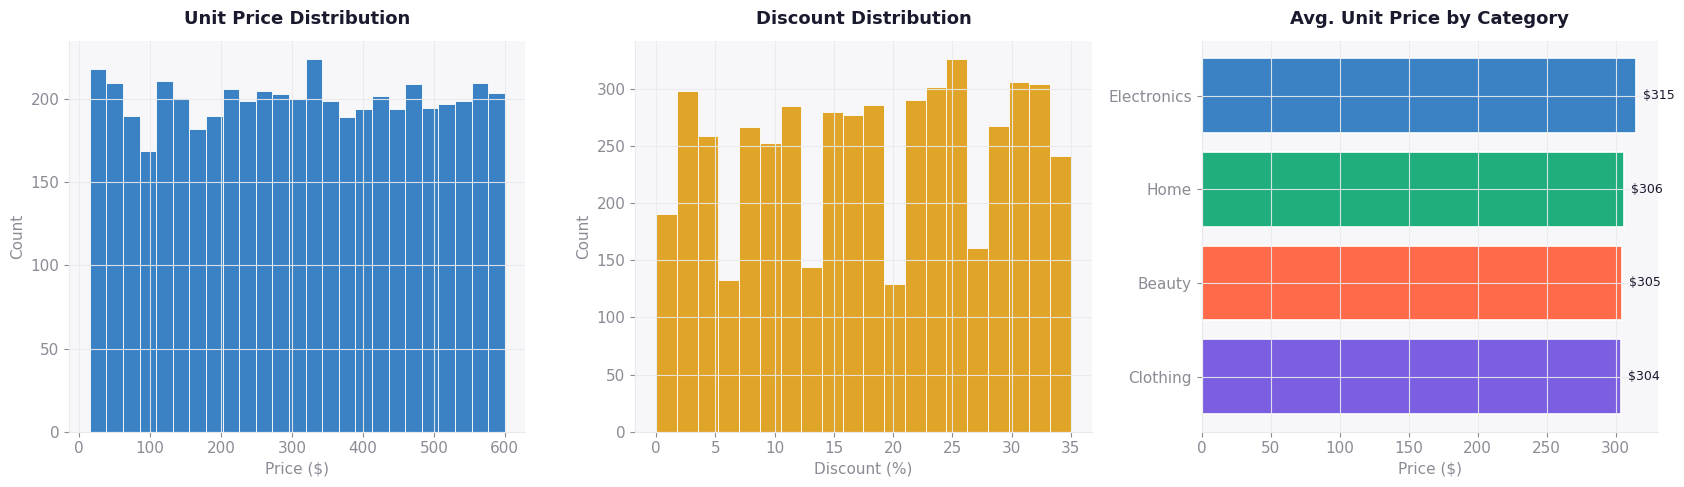

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.hist(df['unit_price'], bins=25, color=BLUE, edgecolor=BG, linewidth=0.6)
style_ax(ax, 'Unit Price Distribution', 'Price ($)', 'Count')

ax = axes[1]
ax.hist(df['discount']*100, bins=20, color=AMBER, edgecolor=BG, linewidth=0.6)
style_ax(ax, 'Discount Distribution', 'Discount (%)', 'Count')

ax = axes[2]
cat_price = df.groupby('product_category')['unit_price'].mean().sort_values()
bars = ax.barh(cat_price.index, cat_price.values, color=[CATEGORY_COLORS[c] for c in cat_price.index], edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+5, b.get_y()+b.get_height()/2, f"${b.get_width():.0f}", va='center', fontsize=9, color=INK)
style_ax(ax, 'Avg. Unit Price by Category', 'Price ($)', '')

plt.tight_layout()
plt.show()


<h2 id="corr" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">🔗 9. Correlation Check</h2>

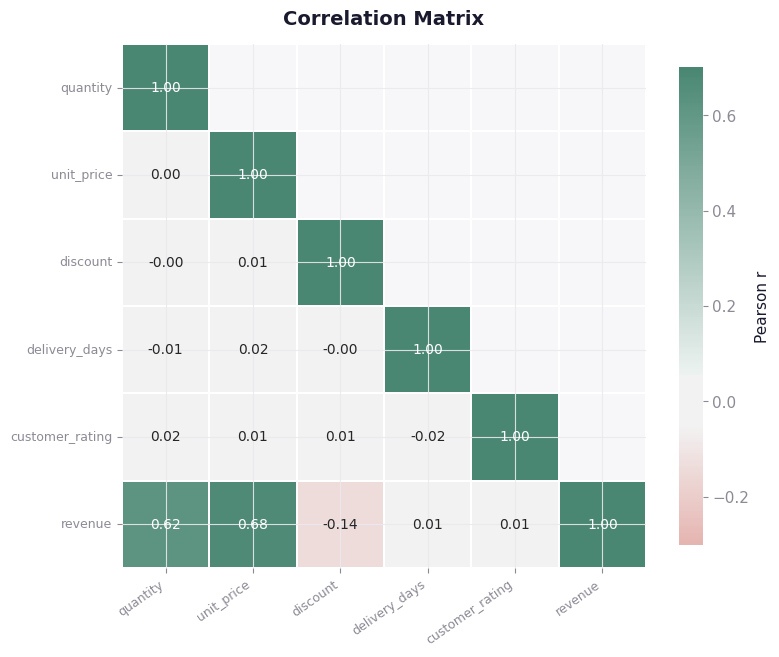

Only revenue's mechanical inputs (quantity, unit_price, discount) show any real correlation with revenue;
every other pair in this matrix sits at |r| < 0.03 — independently drawn fields, exactly as Section 3 found.


In [11]:

num_cols = ['quantity','unit_price','discount','delivery_days','customer_rating','revenue']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
cmap = sns.diverging_palette(15, 160, s=65, l=52, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.3, vmax=0.7,
            square=True, linewidths=1.2, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':10}, ax=ax)
ax.set_title('Correlation Matrix', color=INK, pad=14)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print("Only revenue's mechanical inputs (quantity, unit_price, discount) show any real correlation with revenue;")
print("every other pair in this matrix sits at |r| < 0.03 — independently drawn fields, exactly as Section 3 found.")


<h2 id="dashboard" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">📊 10. Storefront Dashboard</h2>

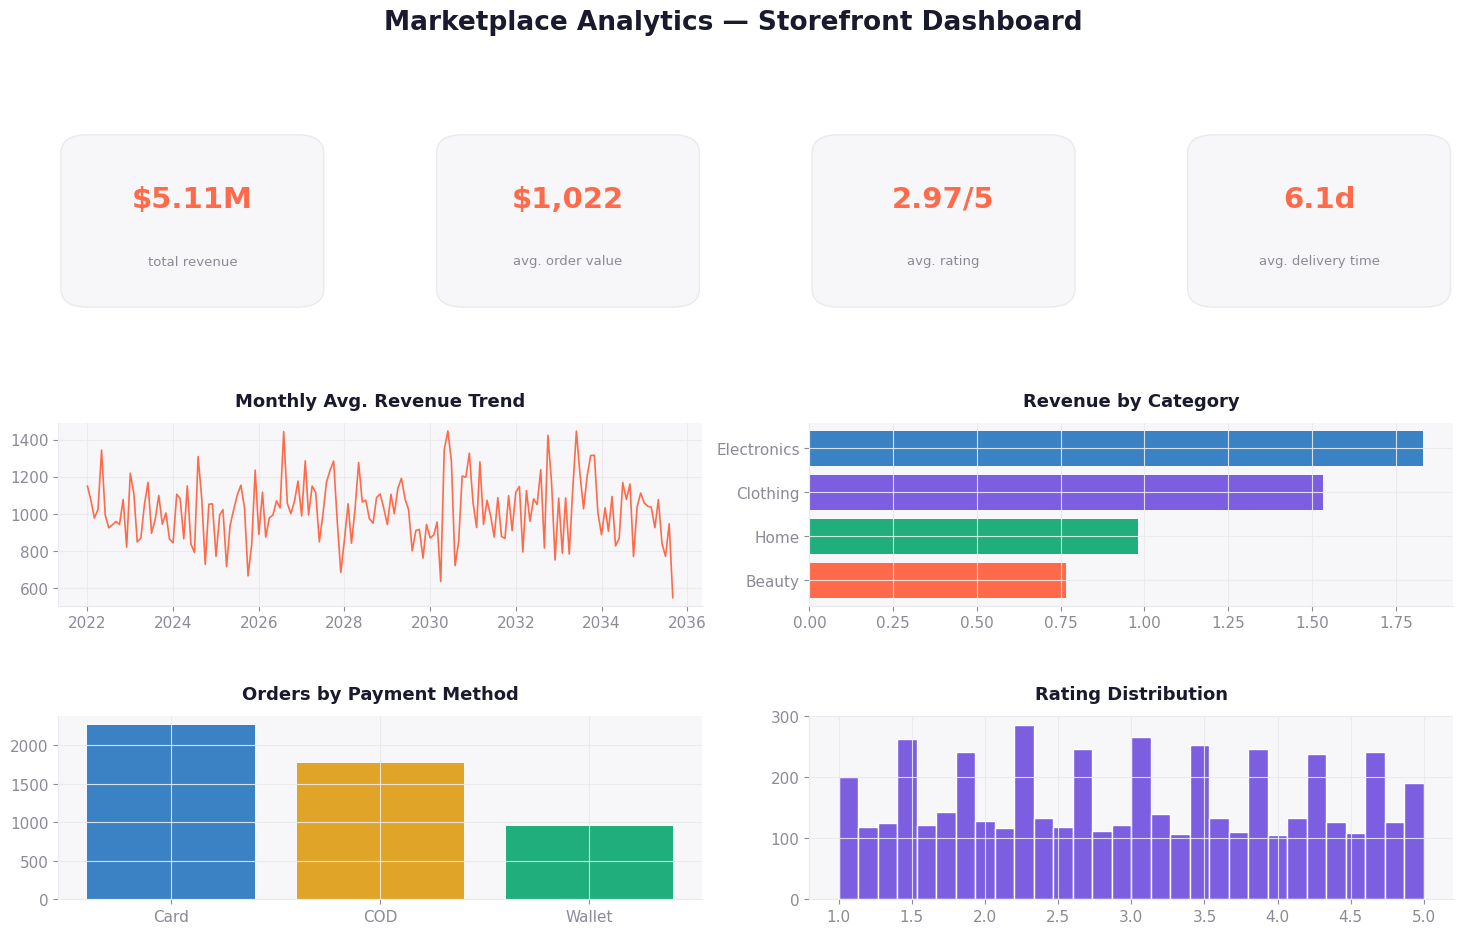

In [12]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Marketplace Analytics — Storefront Dashboard', fontsize=19, color=INK, fontweight='bold', y=1.0)

stat_cells = [
    (f"${df['revenue'].sum()/1e6:.2f}M", "total revenue"),
    (f"${df['revenue'].mean():,.0f}", "avg. order value"),
    (f"{df['customer_rating'].mean():.2f}/5", "avg. rating"),
    (f"{df['delivery_days'].mean():.1f}d", "avg. delivery time"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.10",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=21, color=CORAL, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.28, lab, ha='center', va='center', fontsize=9.5, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
ax.plot(monthly_rev.index, monthly_rev.values, color=CORAL, linewidth=1.2)
style_ax(ax, 'Monthly Avg. Revenue Trend', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.barh(cat_rev.index, cat_rev.values/1e6, color=[CATEGORY_COLORS[c] for c in cat_rev.index])
style_ax(ax, 'Revenue by Category', '', '')

ax = fig.add_subplot(gs[2, :2])
bars = ax.bar(pay_counts.index, pay_counts.values, color=[PAYMENT_COLORS[p] for p in pay_counts.index])
style_ax(ax, 'Orders by Payment Method', '', '')

ax = fig.add_subplot(gs[2, 2:])
ax.hist(df['customer_rating'], bins=30, color=PURPLE, edgecolor=BG)
style_ax(ax, 'Rating Distribution', '', '')

plt.show()


<h2 id="model" style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E; border-bottom:3px solid #FF6B4A; padding-bottom:8px;">🤖 11. Predicting Revenue</h2>
<p style="color:#33333F; font-family:'Segoe UI',Helvetica,Arial,sans-serif; background:#F7F7FA; padding:8px 18px; border-radius:8px;">Given Section 3's finding that <code>revenue</code> is an exact formula of <code>quantity</code>, <code>unit_price</code> and <code>discount</code>, we'd expect a flexible model using those three fields to reach a near-perfect R² — a good sanity check before adding weaker features.</p>

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model_df = df.copy()
cat_cols = ['product_category','region','payment_method']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])

features = ['product_category','region','quantity','unit_price','discount','payment_method',
            'delivery_days','customer_rating']
X = model_df[features]
y = model_df['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

models = {
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    results[name] = {'model': m, 'pred': pred, 'r2': r2, 'mae': mae}
    print(f"{name}: R² = {r2:.4f} | MAE = ${mae:,.2f}")


Train: 4,000 rows | Test: 1,000 rows
Random Forest: R² = 0.9988 | MAE = $18.73
XGBoost: R² = 0.9994 | MAE = $13.59


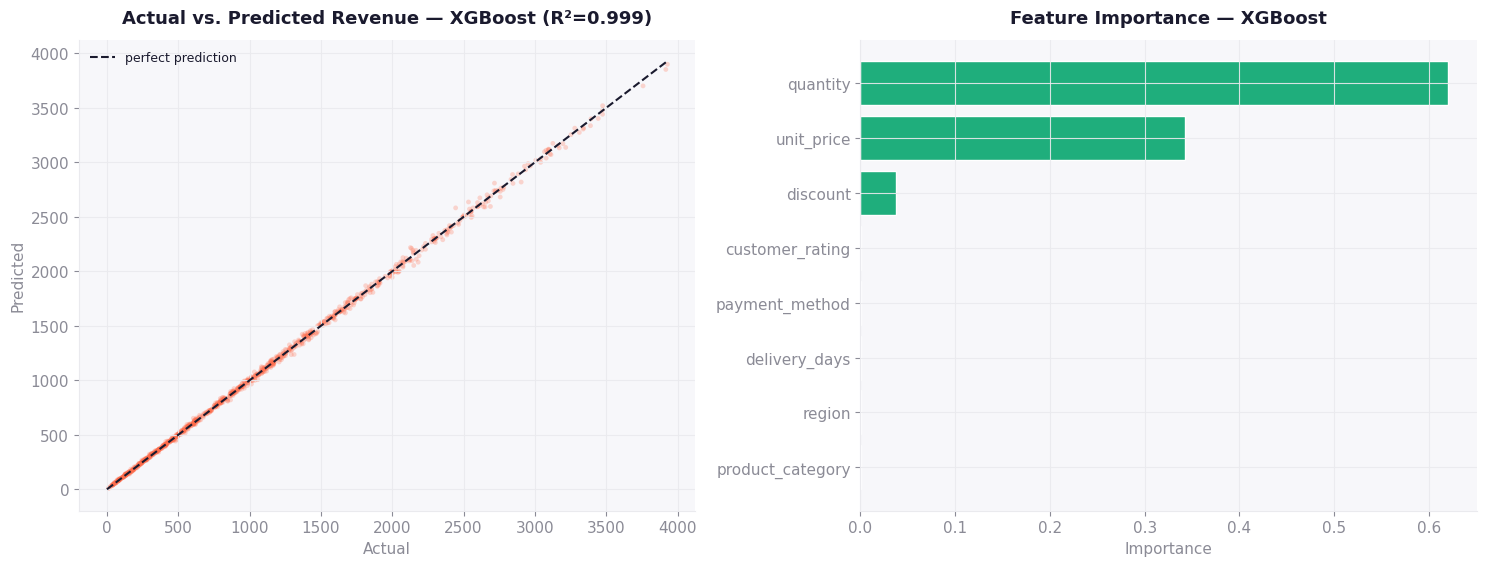

In [14]:

best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.scatter(y_test, best['pred'], alpha=0.25, s=12, color=CORAL, edgecolor='none')
lims = [0, max(y_test.max(), best['pred'].max())]
ax.plot(lims, lims, color=INK, linestyle='--', linewidth=1.5, label='perfect prediction')
style_ax(ax, f'Actual vs. Predicted Revenue — {best_name} (R²={best["r2"]:.3f})', 'Actual', 'Predicted')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
importances = pd.Series(best['model'].feature_importances_, index=features).sort_values()
ax.barh(importances.index, importances.values, color=TEAL, edgecolor=BG)
style_ax(ax, f'Feature Importance — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()



<div style="background:#F0F9F6; border-left:4px solid #1FAE7C; border-radius:8px; padding:16px 22px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#33333F; font-size:14px;">
<b>Confirmed:</b> unit price and quantity dominate feature importance, with discount contributing a smaller but
real share — recovering almost exactly the formula identified in Section 3. Category, region, payment method,
delivery time, and rating barely register, consistent with the correlation matrix showing them as unrelated to
revenue. This is a clean confirmation exercise rather than a discovery — useful for validating the modeling
pipeline, not for claiming these operational factors don't matter to real e-commerce revenue.
</div>



<div style="background:#F7F7FA; padding:36px 40px; border-radius:16px; font-family:'Segoe UI',Helvetica,Arial,sans-serif; color:#1A1A2E;">

<h2 id="conclusion" style="margin-top:0; font-weight:800; color:#1A1A2E; border-bottom:2px solid #EAEAEE; padding-bottom:10px;">📝 12. Closing Notes</h2>

<h4 style="color:#FF6B4A; font-weight:700; margin-bottom:6px;">What the data shows</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#33333F;">
<li>Electronics leads both order volume and total revenue; revenue is otherwise close to evenly split across regions and categories.</li>
<li>Revenue is fully explained by <code>quantity × unit_price × (1 - discount)</code> — confirmed both analytically and by a regression model reaching near-perfect R² using just those three fields.</li>
<li>Payment method, delivery time, and customer rating show no meaningful relationship with revenue, with each other, or with order date — every one of these fields appears to have been generated independently.</li>
</ul>

<h4 style="color:#FF6B4A; font-weight:700; margin-bottom:6px;">What to hold loosely</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#33333F;">
<li>Order dates run through September 2035 — nine years past today — with exactly one order recorded every single calendar day, and customer ratings follow an almost perfectly uniform distribution rather than the skewed shape real review data usually takes. Together, these point to a simulated order log rather than a live transaction history.</li>
<li>Treat the trend charts, regional splits, and payment-method comparisons as a practice ground for the analysis workflow, not as a real store's actual performance record.</li>
</ul>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8B8B96; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
